In [ ]:
# =====================================================
# CODE REFERENCE AND ATTRIBUTION
# =====================================================
# This notebook is developed based on a reference implementation
# provided by Bleedy AI Academy:
#
# Title:
# Human Activity Recognition using TensorFlow CNN-LSTM
#
# Source:
# https://bleedaiacademy.com/human-activity-recognition-using-tensorflow-cnn-lstm/
#
# Original implementation:
# CNN + LSTM architecture
#
# Major modifications in this work:
# - Replaced CNN-LSTM with a 3D CNN architecture
# - Added an explicit train / validation / test split
# - Introduced real-time inference speed evaluation
# - Improved dataset validation and preprocessing
#
# Author: Luong Minh Nhat
# Course: Deep Learning - DELE337829_01
# =====================================================


In [ ]:
# =====================================================
# ENVIRONMENT SETUP – DEPENDENCY INSTALLATION
# =====================================================
# Install MoviePy:
# - A Python library for video processing and manipulation
# - Used in this project to handle video files during
#   preprocessing and action recognition experiments
!pip install moviepy


In [ ]:
# =====================================================
# WARNING HANDLING
# =====================================================
# Suppress SyntaxWarning messages to:
# - Keep notebook output clean and readable
# - Avoid non-critical warning logs during execution
# NOTE:
# This does NOT affect program logic or model behavior.
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)


In [ ]:
# =====================================================
# LIBRARY IMPORTS
# =====================================================
# This section imports all required libraries for:
# - File system operations and randomness control
# - Video frame extraction and processing
# - Deep learning model construction and training
# - Visualization and evaluation
#
# Libraries are grouped by their functional roles
# to improve readability and maintainability.

# ------------------------------
# Core utilities
# ------------------------------
import os                      # File and directory handling
import cv2                     # Video reading and frame processing
import random                  # Random sampling and shuffling
import numpy as np              # Numerical computation
import tensorflow as tf         # Deep learning framework
from collections import deque  # Sliding window for real-time prediction

# ------------------------------
# Visualization
# ------------------------------
import matplotlib.pyplot as plt # Plotting training curves and results
%matplotlib inline              # Display plots directly in the notebook

# ------------------------------
# Video processing
# ------------------------------
from moviepy.editor import VideoFileClip  # High-level video file handling

# ------------------------------
# Machine Learning utilities
# ------------------------------
from sklearn.model_selection import train_test_split          # Train/validation split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # Model evaluation

# ------------------------------
# Keras model components
# ------------------------------
from tensorflow.keras.models import Model, Sequential

from tensorflow.keras.layers import (
    Input,
    Flatten,
    Conv2D,
    Conv3D,                 # Spatio-temporal feature extraction
    MaxPooling2D,
    MaxPooling3D,
    GlobalAveragePooling2D,
    GlobalAveragePooling3D,
    TimeDistributed,        # Apply CNN per frame
    LSTM,                   # Temporal sequence modeling
    Dense,
    Bidirectional,
    Dropout,
    ConvLSTM2D              # Joint spatial-temporal modeling
)

# ------------------------------
# Training utilities
# ------------------------------
from tensorflow.keras.callbacks import (
    EarlyStopping,          # Prevent overfitting
    ModelCheckpoint,        # Save best model
    ReduceLROnPlateau       # Adaptive learning rate
)

# ------------------------------
# Keras utilities
# ------------------------------
from tensorflow.keras.utils import (
    to_categorical,         # One-hot encoding for labels
    plot_model              # Model architecture visualization
)

from tensorflow.keras.regularizers import l2  # Weight regularization


2025-12-31 15:37:57.097602: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767195477.293363      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767195477.352848      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767195477.837742      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767195477.837794      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767195477.837796      24 computation_placer.cc:177] computation placer alr

In [ ]:
# =====================================================
# GLOBAL CONFIGURATION
# =====================================================
# This section defines all global constants and
# hyperparameters used throughout the project.
#
# Purpose:
# - Ensure reproducibility
# - Centralize dataset and model configuration
# - Make experiments easier to control and modify

# ------------------------------
# Random seed for reproducibility
# ------------------------------
SEED = 27
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------
# Dataset configuration
# ------------------------------
# Root directory of the UCF50 dataset
DATASET_DIR = "/kaggle/input/ucf50/UCF50"

# ------------------------------
# Input data configuration
# ------------------------------
# Spatial resolution of each video frame
IMAGE_HEIGHT = 64
IMAGE_WIDTH  = 64

# Number of consecutive frames per video sample
SEQUENCE_LENGTH = 20

# ------------------------------
# Action classes
# ------------------------------
# Selected action categories used for training and evaluation
# NOTE:
# The model is trained only on this subset of UCF50 classes.
CLASSES_LIST = ["WalkingWithDog", "TaiChi", "Swing", "HorseRace"]


In [ ]:
# =====================================================
# DATASET INSPECTION – CLASS DISCOVERY
# =====================================================
# This cell automatically scans the dataset directory to:
# - Identify all available action classes
# - Count the total number of classes in the dataset
#
# Purpose:
# - Verify dataset integrity
# - Provide context when selecting a subset of classes
#   for training (e.g., CLASSES_LIST)

ALL_CLASSES = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])

# Print total number of action classes in the dataset
print("Tổng số class trong dataset:", len(ALL_CLASSES))


Tổng số class trong dataset: 50


In [ ]:
# =====================================================
# CLASS VALIDATION AND SELECTION
# =====================================================
# This cell ensures that:
# - All selected classes actually exist in the dataset
# - Invalid or missing class names are automatically removed
#
# Purpose:
# - Prevent runtime errors caused by incorrect class labels
# - Guarantee consistency between configuration and dataset

# Filter selected classes based on available dataset folders
CLASSES_LIST = [c for c in CLASSES_LIST if c in ALL_CLASSES]

# Display final list of classes used for training
print("Classes dùng để train:")
print(CLASSES_LIST)

# Display number of selected classes
print("Số class:", len(CLASSES_LIST))


Classes dùng để train:
['WalkingWithDog', 'TaiChi', 'Swing', 'HorseRace']
Số class: 4


In [ ]:
# =====================================================
# CLASS LABEL ENCODING
# =====================================================
# This cell creates a mapping between:
# - Human-readable class names
# - Numerical class indices required by the model
#
# Purpose:
# - Convert string labels into integer values
# - Enable one-hot encoding for multi-class classification

# Create a dictionary that maps each class name to a unique index
CLASS_LABELS = {cls: idx for idx, cls in enumerate(CLASSES_LIST)}

# Total number of action classes
NUM_CLASSES = len(CLASSES_LIST)

# Display class-to-index mapping
print(CLASS_LABELS)


{'WalkingWithDog': 0, 'TaiChi': 1, 'Swing': 2, 'HorseRace': 3}


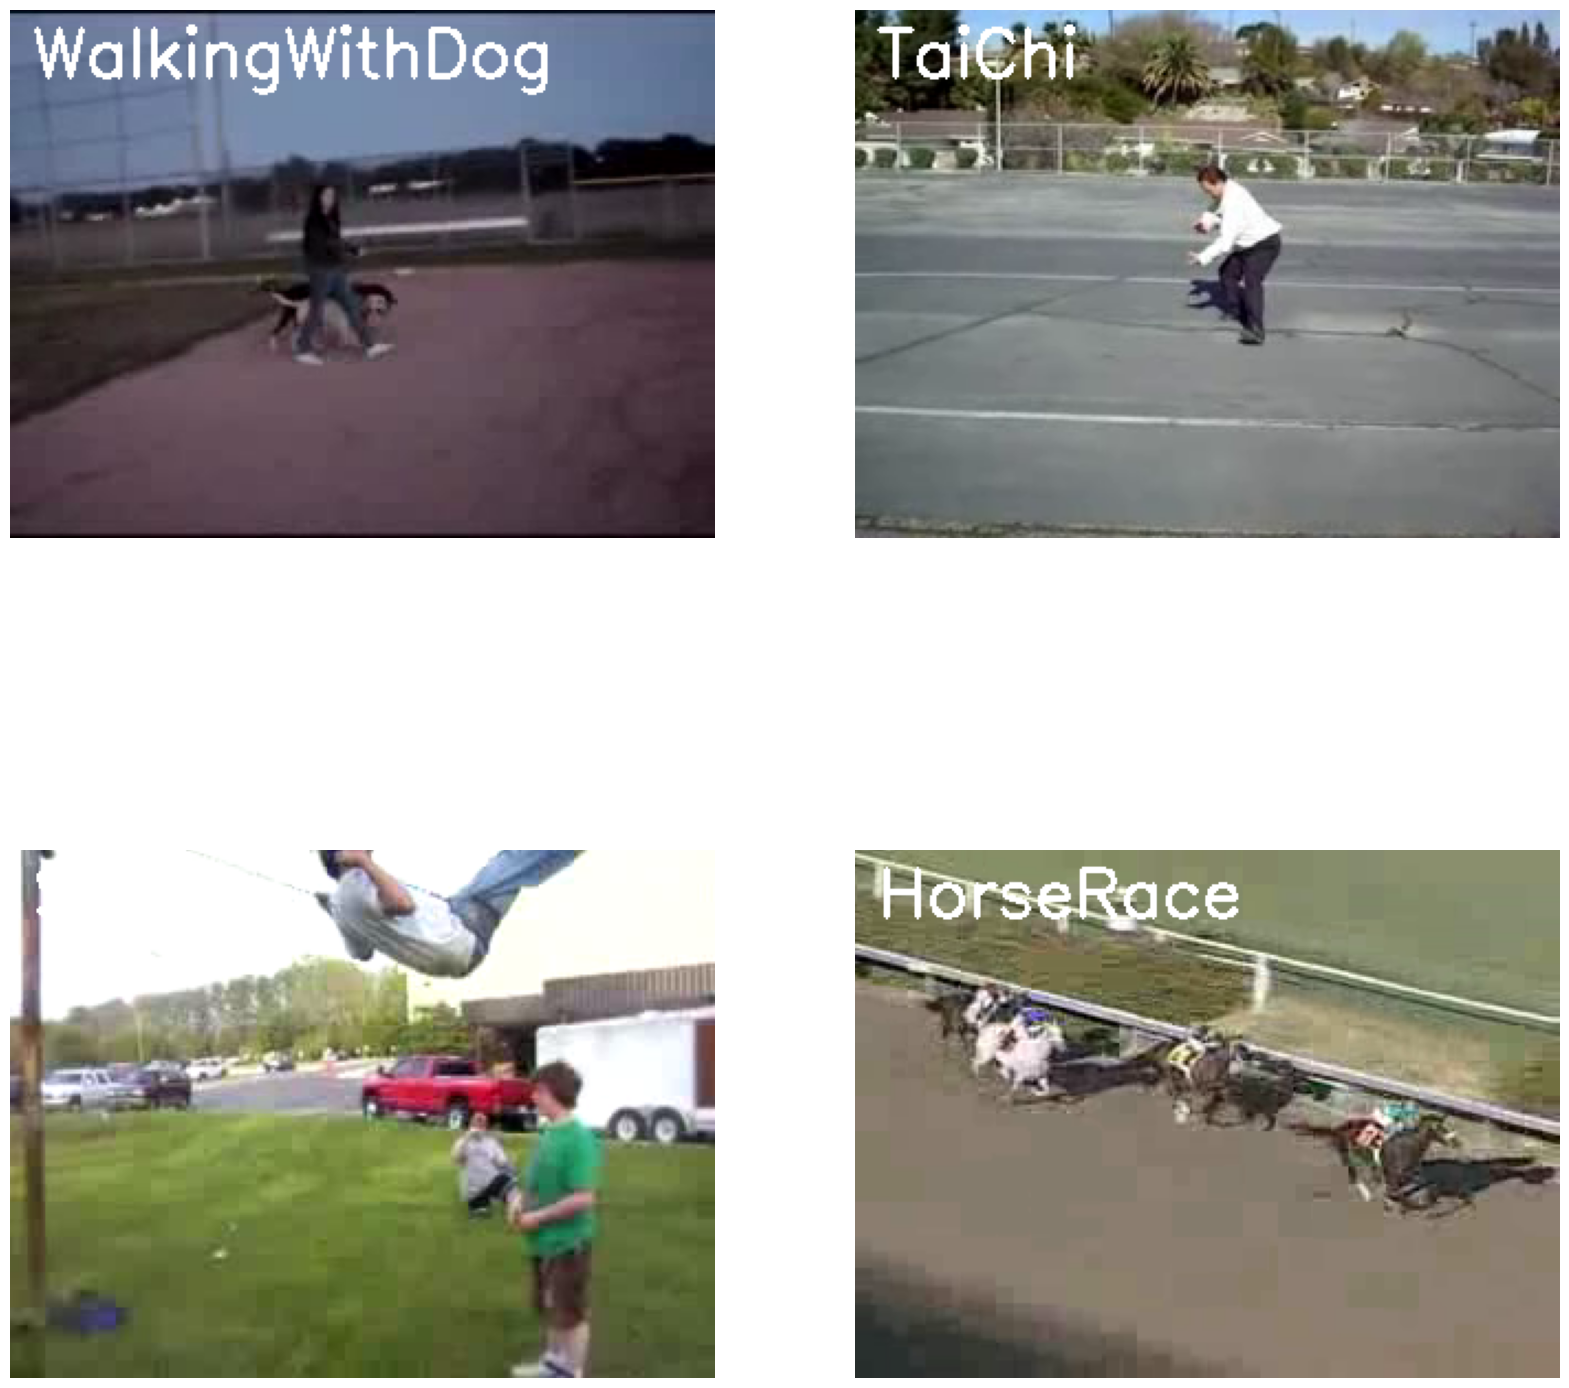

In [ ]:
# =====================================================
# DATASET VISUALIZATION – SAMPLE FRAMES
# =====================================================
# This cell visualizes one representative frame for
# each selected action class.
#
# Procedure:
# - Randomly select a video from each class
# - Extract the middle frame of the video
# - Display the frame with its corresponding class label
#
# Purpose:
# - Provide an intuitive understanding of the dataset
# - Verify data correctness and visual diversity
# - Support dataset description in the report

plt.figure(figsize=(20, 20))

for idx, class_name in enumerate(CLASSES_LIST, 1):

    # Path to the current class directory
    class_path = os.path.join(DATASET_DIR, class_name)

    # List all video files belonging to the class
    video_files = [f for f in os.listdir(class_path) if f.endswith('.avi')]

    # Randomly select one video for visualization
    video_path = os.path.join(class_path, random.choice(video_files))
    cap = cv2.VideoCapture(video_path)

    # Move to the middle frame of the video
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, total_frames // 2)
    success, frame = cap.read()
    cap.release()

    # Skip if frame extraction fails
    if not success:
        continue

    # Convert BGR (OpenCV) to RGB (Matplotlib)
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Overlay class name on the frame
    cv2.putText(frame, class_name, (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    # Display frame in a grid layout
    plt.subplot(2, 2, idx)
    plt.imshow(frame)
    plt.axis('off')


In [ ]:
# =====================================================
# VIDEO FRAME EXTRACTION FUNCTION
# =====================================================
# This function extracts a fixed-length clip from a video
# and converts it into a normalized tensor suitable for
# deep learning models (3D CNN / CNN-LSTM).

def frames_extraction(video_path):
    """
    Extract a continuous clip of SEQUENCE_LENGTH frames
    from the given video file.

    Processing steps:
    - Randomly select a valid starting frame
    - Read SEQUENCE_LENGTH consecutive frames
    - Convert color space from BGR to RGB
    - Resize frames to (IMAGE_HEIGHT, IMAGE_WIDTH)
    - Normalize pixel values to [0, 1]

    Parameters:
        video_path (str): Path to the input video file

    Returns:
        np.ndarray:
            Shape (SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)
            or None if the video is invalid or too short
    """

    frames = []
    cap = cv2.VideoCapture(video_path)

    # Check whether the video file can be opened
    if not cap.isOpened():
        return None

    # Total number of frames in the video
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Skip videos that are shorter than the required sequence length
    if total_frames < SEQUENCE_LENGTH:
        cap.release()
        return None

    # Randomly choose a valid starting frame index
    max_start = total_frames - SEQUENCE_LENGTH
    start_frame = random.randint(0, max_start)

    # Move the video pointer to the starting frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    # Read and process SEQUENCE_LENGTH consecutive frames
    for _ in range(SEQUENCE_LENGTH):
        success, frame = cap.read()
        if not success:
            break

        # Convert frame from BGR (OpenCV) to RGB
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Resize frame to match model input dimensions
        frame = cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))

        # Normalize pixel values for stable training
        frame = frame / 255.0

        frames.append(frame)

    cap.release()

    # Ensure the extracted clip has the required length
    if len(frames) < SEQUENCE_LENGTH:
        return None

    return np.array(frames, dtype=np.float32)


(20, 64, 64, 3)


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

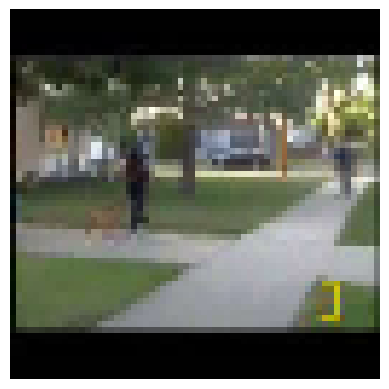

In [ ]:
# =====================================================
# FRAME EXTRACTION VERIFICATION
# =====================================================
# This cell performs a sanity check on the frame extraction
# function by:
# - Selecting a sample video from the dataset
# - Extracting a fixed-length frame sequence
# - Visualizing one frame from the extracted sequence
#
# Purpose:
# - Verify correct frame shape and dimensions
# - Ensure preprocessing steps (resize, normalization, RGB)
#   are applied correctly before training

# Select a sample video from the first class
sample_video = os.path.join(
    DATASET_DIR,
    CLASSES_LIST[0],
    os.listdir(os.path.join(DATASET_DIR, CLASSES_LIST[0]))[0]
)

# Extract frames from the sample video
frames = frames_extraction(sample_video)

# Display extracted tensor shape
print(frames.shape)

# Visualize a representative frame from the sequence
plt.imshow(frames[10])
plt.axis('off')


In [ ]:
# =====================================================
# DATASET CREATION FUNCTION
# =====================================================
# This function constructs the training dataset by:
# - Iterating through selected action classes
# - Extracting frame sequences from each video
# - Assigning numerical labels to each sample
#
# The resulting dataset is suitable for
# spatio-temporal models such as 3D CNN or CNN + LSTM.

def create_dataset(max_videos_per_class=None):
    """
    Create a dataset from raw video files.

    Processing steps:
    - Loop through each selected action class
    - Read all videos belonging to the class
    - Extract SEQUENCE_LENGTH frames per video
    - Assign a numerical label to each video sample

    Parameters:
        max_videos_per_class (int, optional):
            Maximum number of videos to load per class.
            Useful for debugging or reducing training time.

    Returns:
        X (np.ndarray):
            Shape (N, SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)
            Extracted video frame sequences
        y (np.ndarray):
            Shape (N,)
            Integer class labels
        video_paths (list):
            List of original video file paths
    """

    features = []      # Store extracted frame sequences
    labels = []        # Store corresponding class indices
    video_paths = []   # Store video file paths for reference

    for class_index, class_name in enumerate(CLASSES_LIST):
        print(f'\nExtracting class: {class_name}')

        # Path to current class directory
        class_path = os.path.join(DATASET_DIR, class_name)

        # List all video files for the current class
        video_files = [
            f for f in os.listdir(class_path)
            if f.endswith('.avi')
        ]

        # Optionally limit the number of videos per class
        if max_videos_per_class:
            video_files = video_files[:max_videos_per_class]

        valid_count = 0

        for file_name in video_files:
            video_path = os.path.join(class_path, file_name)

            # Extract frames from the current video
            frames = frames_extraction(video_path)

            # Skip broken or short videos
            if frames is None:
                continue

            features.append(frames)
            labels.append(class_index)
            video_paths.append(video_path)
            valid_count += 1

        # Report number of valid videos used for the class
        print(f'Valid videos used: {valid_count}')

    # Convert lists to NumPy arrays
    X = np.array(features, dtype=np.float32)
    y = np.array(labels)

    return X, y, video_paths


In [ ]:
# =====================================================
# DATASET GENERATION
# =====================================================
# Create the training dataset by extracting frame sequences
# from raw video files.
#
# Parameter:
# - max_videos_per_class = 150
#   Limits the number of videos loaded per class to:
#   - Reduce memory usage
#   - Control training time
#   - Ensure balanced data loading across classes

# Create the dataset
features, labels, paths = create_dataset(max_videos_per_class=150)



Extracting class: WalkingWithDog
Valid videos used: 123

Extracting class: TaiChi
Valid videos used: 100

Extracting class: Swing
Valid videos used: 137

Extracting class: HorseRace
Valid videos used: 127


In [ ]:
# =====================================================
# LABEL ENCODING
# =====================================================
# Convert integer class labels into one-hot encoded vectors.
#
# Purpose:
# - Prepare labels for multi-class classification
# - Match the output format required by Softmax activation
#   and categorical cross-entropy loss function

# Number of action classes
NUM_CLASSES = len(CLASSES_LIST)

# One-hot encode class labels
one_hot_encoded_labels = to_categorical(labels, num_classes=NUM_CLASSES)


In [ ]:
# =====================================================
# DATASET SPLITTING: TRAIN / VALIDATION / TEST
# =====================================================
# This cell splits the dataset into three disjoint subsets:
# - Training set: used to update model parameters
# - Validation set: used for hyperparameter tuning and
#   overfitting monitoring
# - Test set: used for final, unbiased model evaluation
#
# Stratified sampling is applied to preserve
# class distribution across all subsets.

# Convert one-hot encoded labels back to integer form
# (used for stratified splitting)
labels_int = np.argmax(one_hot_encoded_labels, axis=1)

# ------------------------------
# 1. Split TEST set first (20%)
# ------------------------------
features_trainval, features_test, labels_trainval, labels_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=SEED,
    shuffle=True,
    stratify=labels
)

# ------------------------------
# 2. Split VALIDATION set from remaining data (20%)
# ------------------------------
features_train, features_val, labels_train, labels_val = train_test_split(
    features_trainval,
    labels_trainval,
    test_size=0.2,
    random_state=SEED,
    shuffle=True,
    stratify=labels_trainval
)

# Display dataset sizes
print("Train:", features_train.shape)
print("Val  :", features_val.shape)
print("Test :", features_test.shape)


Train: (311, 20, 64, 64, 3)
Val  : (78, 20, 64, 64, 3)
Test : (98, 20, 64, 64, 3)


In [ ]:
# =====================================================
# 3D CNN MODEL DEFINITION
# =====================================================
# This function defines a 3D Convolutional Neural Network
# for video-based action recognition.
#
# The model processes a sequence of video frames and
# learns spatial-temporal features directly using 3D convolutions.

def create_3d_cnn_model():
    """
    Build a 3D CNN model for action recognition.

    Model characteristics:
    - Input: sequence of RGB frames
      (SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)
    - 3D convolution layers capture both spatial and temporal patterns
    - Global Average Pooling reduces parameters and overfitting
    - Softmax output for multi-class classification

    Returns:
        tensorflow.keras.Model:
            Compiled 3D CNN architecture (uncompiled state)
    """

    # Input layer for video sequences
    input_layer = Input(
        shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)
    )

    # ------------------------------
    # Block 1: Low-level spatio-temporal features
    # ------------------------------
    x = Conv3D(32, (3,3,3), activation='relu', padding='same')(input_layer)
    x = MaxPooling3D((1,2,2))(x)   # Preserve temporal resolution
    x = Dropout(0.25)(x)

    # ------------------------------
    # Block 2: Mid-level spatio-temporal features
    # ------------------------------
    x = Conv3D(64, (3,3,3), activation='relu', padding='same')(x)
    x = MaxPooling3D((2,2,2))(x)
    x = Dropout(0.3)(x)

    # ------------------------------
    # Block 3: High-level spatio-temporal features
    # ------------------------------
    x = Conv3D(128, (3,3,3), activation='relu', padding='same')(x)
    x = MaxPooling3D((2,2,2))(x)
    x = Dropout(0.4)(x)

    # Global pooling to aggregate temporal and spatial information
    x = GlobalAveragePooling3D()(x)

    # Fully connected layers for classification
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    # Output layer with Softmax activation
    output = Dense(NUM_CLASSES, activation='softmax')(x)

    return Model(input_layer, output)


In [ ]:
# =====================================================
# MODEL INITIALIZATION AND COMPILATION
# =====================================================
# This cell:
# - Instantiates the 3D CNN model
# - Configures the training process by specifying
#   optimizer, loss function, and evaluation metrics

# Create the 3D CNN model architecture
model = create_3d_cnn_model()

# Compile the model with training configuration
model.compile(
    optimizer="adam",                         # Adaptive optimization algorithm
    loss="sparse_categorical_crossentropy",   # Suitable for integer class labels
    metrics=["accuracy"]                      # Classification performance metric
)


I0000 00:00:1767195502.789644      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


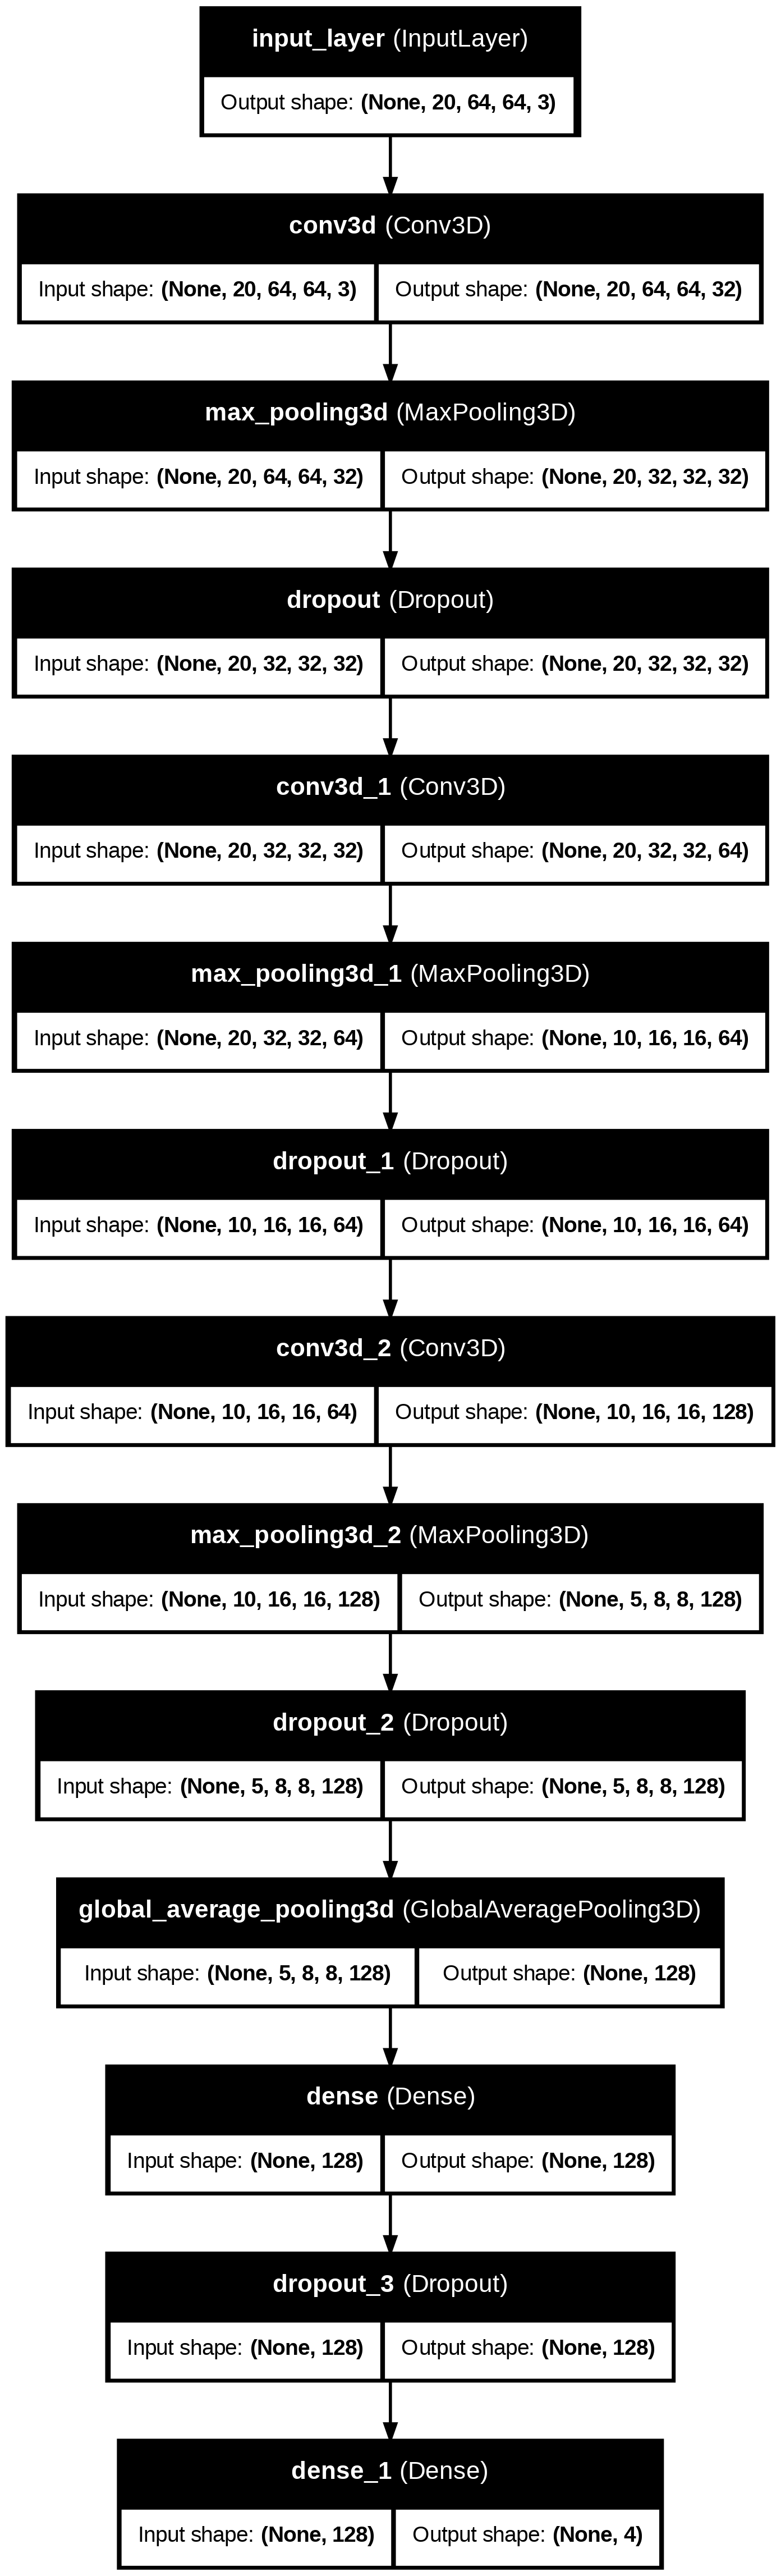

In [ ]:
# =====================================================
# MODEL ARCHITECTURE VISUALIZATION
# =====================================================
# This cell generates a visual diagram of the constructed model.
#
# Purpose:
# - Provide a clear overview of the network architecture
# - Display layer types, connections, and tensor shapes
# - Support model explanation in the project report

# Plot and save the model architecture diagram
plot_model(
    model,
    to_file='model_structure_plot.png',
    show_shapes=True,
    show_layer_names=True
)


In [ ]:
# =====================================================
# TRAINING CALLBACKS CONFIGURATION
# =====================================================
# Callbacks are used to:
# - Improve training stability
# - Prevent overfitting
# - Automatically save the best-performing model
# - Adjust learning rate during training

# ------------------------------
# Early Stopping
# ------------------------------
# Stops training when validation loss stops improving
# and restores the model weights from the best epoch.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# ------------------------------
# Model Checkpoint
# ------------------------------
# Saves the model that achieves the highest validation accuracy.
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

# ------------------------------
# Learning Rate Scheduler
# ------------------------------
# Reduces learning rate when validation loss plateaus
# to help the model converge more effectively.
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)


In [ ]:
# =====================================================
# MODEL TRAINING
# =====================================================
# This cell trains the 3D CNN model using the prepared dataset.
#
# Training setup:
# - Training data: features_train, labels_train
# - Validation data: features_val, labels_val
# - Early stopping and model checkpoint callbacks
#
# Purpose:
# - Learn spatio-temporal patterns from video sequences
# - Monitor generalization performance on validation set

history = model.fit(
    features_train, labels_train,
    epochs=100,                           # Maximum number of training epochs
    batch_size=4,                         # Small batch size due to memory constraints
    validation_data=(features_val, labels_val),
    callbacks=[early_stop, checkpoint],   # Overfitting prevention & best model saving
    shuffle=True                          # Shuffle data each epoch for better generalization
)


Epoch 1/100


I0000 00:00:1767195507.131105    2045 service.cc:152] XLA service 0x7cefd40272f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767195507.131144    2045 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1767195507.535240    2045 cuda_dnn.cc:529] Loaded cuDNN version 91002


 6/78 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.1958 - loss: 1.4282

I0000 00:00:1767195512.485997    2045 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


78/78 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - accuracy: 0.2638 - loss: 1.4343 - val_accuracy: 0.2949 - val_loss: 1.3843
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.2706 - loss: 1.3833 - val_accuracy: 0.2821 - val_loss: 1.3824
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.2348 - loss: 1.3805 - val_accuracy: 0.2821 - val_loss: 1.3688
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.2424 - loss: 1.3969 - val_accuracy: 0.4103 - val_loss: 1.2980
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.2967 - loss: 1.3749 - val_accuracy: 0.4231 - val_loss: 1.2544
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.2875 - loss: 1.3559 - val_accuracy: 0.4744 - val_loss: 1.1933
Epoch 7/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.2944 - loss: 1.3564 - val_accuracy: 0.4103 - val_loss: 1.2173
Epoch 8/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3019 - loss: 1.3163 - val_accuracy: 0.4487 - val_

In [ ]:
# =====================================================
# TRAINING PERFORMANCE ANALYSIS
# =====================================================
# This cell identifies the best training epoch based on
# validation loss and reports the corresponding metrics.
#
# Purpose:
# - Select the model state with best generalization
# - Compare training and validation performance
# - Support quantitative analysis in the report

# Identify the epoch with the minimum validation loss
best_epoch = np.argmin(history.history['val_loss'])

# Display performance metrics at the best epoch
print("Best epoch:", best_epoch + 1)
print("Train accuracy:", history.history['accuracy'][best_epoch])
print("Train loss:", history.history['loss'][best_epoch])
print("Val accuracy:", history.history['val_accuracy'][best_epoch])
print("Val loss:", history.history['val_loss'][best_epoch])


Best epoch: 73
Train accuracy: 0.9935691356658936
Train loss: 0.0272963996976614
Val accuracy: 0.9487179517745972
Val loss: 0.15610869228839874


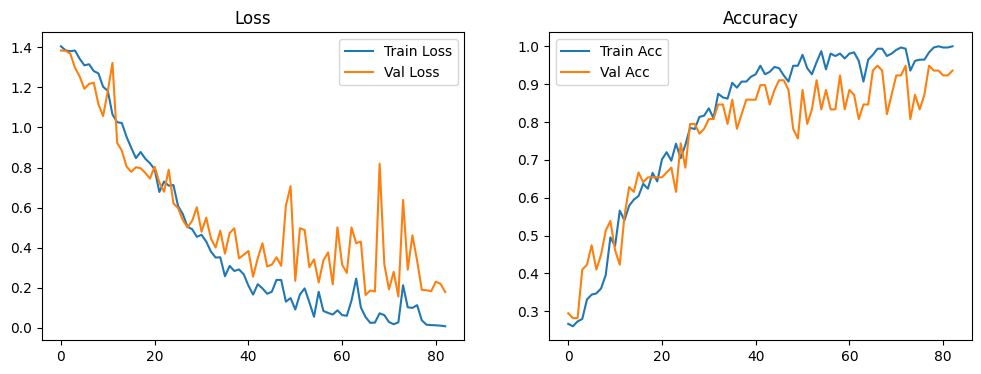

In [ ]:
# =====================================================
# TRAINING CURVES VISUALIZATION
# =====================================================
# This cell visualizes the learning dynamics of the model
# across training epochs.
#
# Plots:
# - Training vs. validation loss
# - Training vs. validation accuracy
#
# Purpose:
# - Analyze convergence behavior
# - Detect overfitting or underfitting
# - Support qualitative evaluation in the report

plt.figure(figsize=(12,4))

# ------------------------------
# Loss curves
# ------------------------------
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

# ------------------------------
# Accuracy curves
# ------------------------------
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.show()


In [ ]:
# =====================================================
# TEST SET EVALUATION
# =====================================================
# This cell evaluates the trained model on the test set,
# which has NOT been used during training or validation.
#
# Purpose:
# - Measure the final generalization performance
# - Provide an unbiased estimate of model effectiveness

print("===== TEST SET EVALUATION =====")

# Evaluate model performance on unseen test data
test_loss, test_acc = model.evaluate(
    features_test,
    labels_test,
    batch_size=4,
    verbose=1
)

# Display test performance metrics
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")


===== TEST SET EVALUATION =====
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9241 - loss: 0.2852
Test accuracy: 0.9082
Test loss: 0.3726


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step


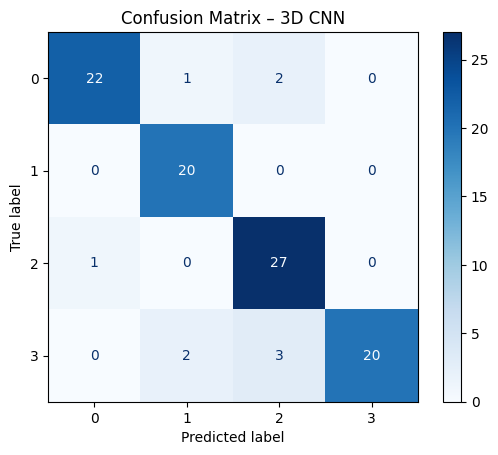

In [ ]:
# =====================================================
# TEST SET PREDICTION AND CONFUSION MATRIX
# =====================================================
# This cell performs detailed evaluation on the test set by:
# - Generating class predictions
# - Comparing predicted labels with ground truth
# - Visualizing classification performance using a confusion matrix
#
# Purpose:
# - Analyze per-class performance
# - Identify common misclassification patterns
# - Support qualitative error analysis in the report

# Generate predictions on the test set
y_pred = model.predict(features_test)

# Convert predicted probabilities to class indices
y_pred_classes = np.argmax(y_pred, axis=1)

# Ground-truth labels (already in integer form)
y_true = labels_test

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Visualize confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix – 3D CNN")
plt.show()


In [ ]:
# =====================================================
# CLASSIFICATION REPORT
# =====================================================
# This cell generates a detailed classification report
# for the test set predictions.
#
# Metrics reported for each class:
# - Precision: correctness of positive predictions
# - Recall: ability to detect all instances of a class
# - F1-score: harmonic mean of precision and recall
#
# Purpose:
# - Provide a class-wise quantitative evaluation
# - Complement confusion matrix analysis
# - Support result discussion in the report

from sklearn.metrics import classification_report

print("Classification Report – 3D CNN")

# Display precision, recall, F1-score, and support
print(classification_report(
    labels_test,
    y_pred_classes,
    digits=4
))


Classification Report – 3D CNN
              precision    recall  f1-score   support

           0     0.9565    0.8800    0.9167        25
           1     0.8696    1.0000    0.9302        20
           2     0.8438    0.9643    0.9000        28
           3     1.0000    0.8000    0.8889        25

    accuracy                         0.9082        98
   macro avg     0.9175    0.9111    0.9089        98
weighted avg     0.9176    0.9082    0.9076        98



In [ ]:
# =====================================================
# CLASSIFICATION REPORT AS DATAFRAME
# =====================================================
# This cell converts the classification report into a
# tabular format using pandas.
#
# Purpose:
# - Improve readability of evaluation metrics
# - Enable easy export to tables or reports (e.g., Word/LaTeX)
# - Facilitate further analysis and visualization

import pandas as pd
from sklearn.metrics import classification_report

# Generate classification report in dictionary format
report_dict = classification_report(
    labels_test,
    y_pred_classes,
    output_dict=True
)

# Convert report dictionary to pandas DataFrame
df_report = pd.DataFrame(report_dict).transpose()

# Round values for cleaner presentation
df_report = df_report.round(3)

# Display the classification report table
df_report


,precision,recall,f1-score,support
0,0.957,0.880,0.917,25.000
1,0.870,1.000,0.930,20.000
2,0.844,0.964,0.900,28.000
3,1.000,0.800,0.889,25.000
accuracy,0.908,0.908,0.908,0.908
macro avg,0.917,0.911,0.909,98.000
weighted avg,0.918,0.908,0.908,98.000


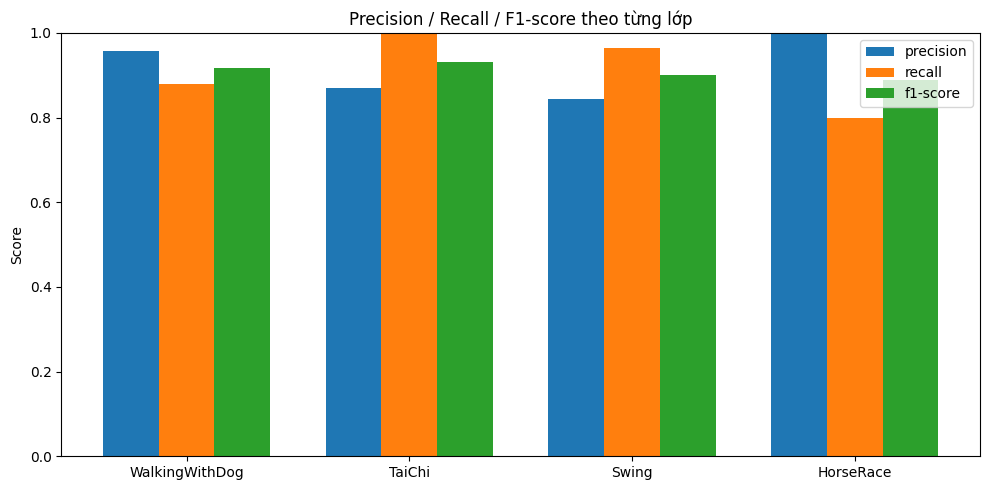

In [ ]:
# =====================================================
# CLASS-WISE METRIC VISUALIZATION
# =====================================================
# This cell visualizes precision, recall, and F1-score
# for each action class using a grouped bar chart.
#
# Purpose:
# - Compare classification performance across classes
# - Identify strengths and weaknesses of the model
# - Support detailed result analysis in the report

import matplotlib.pyplot as plt
import numpy as np

# Select only class rows (exclude average rows)
classes = df_report.index[:-3]  # remove avg rows
metrics = ["precision", "recall", "f1-score"]

# X-axis positions
x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10, 5))

# Plot grouped bars for each metric
for i, metric in enumerate(metrics):
    plt.bar(
        x + i * width,
        df_report.loc[classes, metric],
        width,
        label=metric
    )

# Configure plot appearance
plt.xticks(x + width, CLASSES_LIST, rotation=0)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Precision / Recall / F1-score theo từng lớp")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# =====================================================
# INFERENCE SPEED EVALUATION (REAL-TIME ANALYSIS)
# =====================================================
# This cell measures the inference speed of the trained model
# and evaluates whether it satisfies real-time processing requirements.
#
# Method:
# - Run prediction on multiple test samples
# - Measure total inference time
# - Compute average inference time per video
#
# Purpose:
# - Quantitatively assess real-time capability
# - Support practical applicability discussion in the report

import time

# ------------------------------
# 1. Select test samples for benchmarking
# ------------------------------
# Use multiple samples to average inference time
# and reduce measurement noise caused by system fluctuations.
sample_size = 50
sample_input = features_test[:sample_size]

print(f"Đang đo tốc độ xử lý trên {sample_size} video...")

# ------------------------------
# 2. Start timing
# ------------------------------
start_time = time.time()

# ------------------------------
# 3. Perform inference (disable verbose to avoid overhead)
# ------------------------------
model.predict(sample_input, verbose=0)

# ------------------------------
# 4. End timing
# ------------------------------
end_time = time.time()

# ------------------------------
# 5. Compute inference statistics
# ------------------------------
total_time = end_time - start_time
avg_time_per_video = total_time / sample_size

print(f"\n--- KẾT QUẢ ĐO TỐC ĐỘ ---")
print(f"Tổng thời gian: {total_time:.4f} giây")
print(f"Thời gian trung bình mỗi video: {avg_time_per_video:.4f} giây")

# ------------------------------
# 6. Compare with real-time constraint
# ------------------------------
# Assume:
# - Video recorded at 30 FPS
# - Each input clip consists of SEQUENCE_LENGTH frames
#
# Real-time duration of one clip:
video_duration_real = SEQUENCE_LENGTH / 30 

print(f"Thời gian thực tế của clip (20 frames @ 30fps): {video_duration_real:.4f} giây")

# Determine whether the model satisfies real-time processing
if avg_time_per_video < video_duration_real:
    print("==> KẾT LUẬN: Mô hình ĐẠT khả năng xử lý Real-time.")
    print(f"    (Xử lý nhanh hơn {video_duration_real/avg_time_per_video:.1f} lần so với thực tế)")
else:
    print("==> KẾT LUẬN: Chưa đạt Real-time.")
